# Decoder-only Transformer trained on FineWeb-Edu
## Baseline configuration with GPT-2 BPE tokenizer

In [69]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import math
import time
import gc
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from datasets import load_dataset

In [70]:
device = torch.device("cuda")
print(device)
if torch.cuda.is_available():
    print('cuda available with GPU:',torch.cuda.get_device_name(0))

cuda
cuda available with GPU: NVIDIA GeForce RTX 5080


## Tokenizer
Swap this block to test different tokenizers.  
The rest of the pipeline reads `tokenizer.vocab_size` and `tokenizer.eos_token_id`.

In [71]:
# --- Tokenizer (swap this block for ablation experiments) ---
tokenizer = AutoTokenizer.from_pretrained("gpt2")
vocab_size = tokenizer.vocab_size  # 50257
eos_token_id = tokenizer.eos_token_id  # 50256
print(f"Tokenizer: {tokenizer.__class__.__name__}")
print(f"Vocabulary size: {vocab_size}")
print(f"EOS token id: {eos_token_id}")

Tokenizer: GPT2Tokenizer
Vocabulary size: 50257
EOS token id: 50256


## Data pipeline
Stream FineWeb-Edu from HuggingFace. Documents are tokenized, separated by EOS, and packed into `(seq_length, batch_size)` chunks — the same tensor shape the model expects.

In [72]:
def streaming_token_batcher(dataset_iter, tokenizer, batch_size, seq_length):
    """
    Yields (data, target) tuples of shape (seq_length, batch_size).
    Concatenates tokenized documents (separated by EOS) into a flat buffer,
    then carves out chunks matching the tensor contract the model expects.
    """
    buffer = []
    chunk_size = batch_size * (seq_length + 1)  # +1 for the target offset

    for example in dataset_iter:
        tokens = tokenizer.encode(example["text"])
        tokens.append(eos_token_id)
        buffer.extend(tokens)

        while len(buffer) >= chunk_size:
            chunk = torch.LongTensor(buffer[:chunk_size])
            buffer = buffer[chunk_size:]

            chunk = chunk.view(batch_size, seq_length + 1)
            data   = chunk[:, :seq_length].t().contiguous()    # (seq_length, batch_size)
            target = chunk[:, 1:seq_length+1].t().contiguous() # (seq_length, batch_size)
            yield data, target


def get_epoch_batches(tokens_per_epoch, batch_size, seq_length, tokenizer,
                      dataset_name="HuggingFaceFW/fineweb-edu",
                      subset="sample-10BT", split="train", seed=0,
                      max_retries=5):
    """Stream one epoch's worth of training batches, with retry on network errors."""
    batches_per_epoch = tokens_per_epoch // (batch_size * seq_length)
    batches_yielded = 0

    while batches_yielded < batches_per_epoch:
        try:
            ds = load_dataset(dataset_name, name=subset, split=split, streaming=True)
            ds = ds.shuffle(seed=seed)
            batcher = streaming_token_batcher(ds, tokenizer, batch_size, seq_length)

            for i, (data, target) in enumerate(batcher):
                if i < batches_yielded:
                    continue
                if batches_yielded >= batches_per_epoch:
                    break
                yield data, target
                batches_yielded += 1

            break  # finished normally

        except (RuntimeError, ConnectionError, OSError) as e:
            max_retries -= 1
            if max_retries <= 0:
                raise
            print(f"  [data] stream error: {e}, retrying ({max_retries} left)...")
            time.sleep(10)
        finally:
            try:
                batcher.close()
            except:
                pass
            del ds
            gc.collect()


def load_eval_buffer(tokenizer, batch_size, num_tokens=500_000,
                     dataset_name="HuggingFaceFW/fineweb-edu",
                     subset="sample-10BT", split="train"):
    """Pre-load a small eval buffer from a different region of the stream."""
    ds = load_dataset(dataset_name, name=subset, split=split, streaming=True)
    # skip ahead to avoid overlap with training data
    ds = ds.skip(50_000)
    buffer = []
    for example in ds:
        tokens = tokenizer.encode(example["text"])
        tokens.append(eos_token_id)
        buffer.extend(tokens)
        if len(buffer) >= num_tokens:
            break
    buffer = buffer[:num_tokens]
    del ds
    gc.collect()
    data = torch.LongTensor(buffer)
    # batchify: same layout as PTB
    nbatch = data.size(0) // batch_size
    data = data.narrow(0, 0, nbatch * batch_size)
    data = data.view(batch_size, -1).t().contiguous()
    return data

## Model architecture
Identical to the template transformer — sinusoidal PE, pre-norm decoder blocks, ReLU MLP.

In [73]:
# sinusoidal PE
def generate_positional_encoding(seq_length, dim):
    assert dim == 2* (dim//2) # check if dim is divisible by 2
    pe = torch.zeros(seq_length, dim)
    position = torch.arange(0, seq_length, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, dim, 2).float() * (-torch.log(torch.tensor(10000.0)) / dim))
    pe[:,0::2] = torch.sin(position * div_term)
    pe[:,1::2] = torch.cos(position * div_term)
    return pe

In [74]:
# # One attention head
# class AttentionHead(nn.Module):
#     def __init__(self, d, d_head, dropout):
#         super().__init__()
#         self.LN_MHA = nn.LayerNorm(d_head)
#         self.LN_MLP = nn.LayerNorm(d_head)
#         self.query = nn.Linear(d, d_head, bias=False) # query embedding layer
#         self.key = nn.Linear(d, d_head, bias=False) # key embedding layer
#         self.value = nn.Linear(d, d_head) # value embedding layer
#         self.dropout = nn.Dropout(dropout) # only used in naive attn, not needed for flashattn

#     def forward(self, H): # size(H)=[batch_size, seq_length, d]
#         batch_size = H.size(0); batch_len = H.size(1) # only used in naive attn, not needed for flashattn
              
#         Q = self.query(H) # size=[batch_size, batch_length, d_head]        
#         K = self.key(H) # size=[batch_size, batch_length, d_head]
#         V = self.value(H) # size=[batch_size, batch_length, d_head]

#         ## Naive attn implementation ##
#         # attention_score = (Q @ K.transpose(-2, -1)) / math.sqrt(Q.size(2)) # QK^T/sqrt(d), (B,L,d) @ (B,d,L) => (B,L,L), size=[batch_size, batch_length, batch_length)
#         # mask = torch.tril(torch.ones(batch_len,batch_len)).long().to(device) # mask to use previous tokens only : { token(<=t) }, size=[batch_len,batch_len]
#         # attention_score = attention_score.masked_fill(mask==0, value=float('-inf')) # softmax(-inf)=0 prevents using next tokens for prediction, size=(batch_size, batch_len, batch_len)
#         # attention_score = torch.softmax(attention_score, dim=-1) # softmax over rows. sum weights = 1, size=[batch_size, batch_length, batch_len)
#         # attention_score = self.dropout(attention_score) # dropout attention scores
#         # H_HA = attention_score @ V # softmax( QK^T / sqrt(d) ) V, (B,L,L) @ (B,L,d) => (B,L,d), size=[batch_size, batch_length, d)
#         ## End Naive attn implementation ##
        
#         H_HA = F.scaled_dot_product_attention(Q, K, V, is_causal=True)
#         return H_HA # return prediction scores for next token

In [75]:
# One MHA block
class MultipleAttentionHead(nn.Module):
    def __init__(self, d, num_heads, dropout):
        super().__init__()
        d_head = d // num_heads # dim_head = d // num_heads, usually dimension per head is 64
        assert d == d_head * num_heads # check divisibility
        self.WQ = nn.Linear(d, d, bias=False)
        self.WK = nn.Linear(d, d, bias=False)
        self.WV = nn.Linear(d, d, bias=False)
        self.WO = nn.Linear(d, d) # combination layer
        self.dropout_p = dropout
        self.num_heads = num_heads
        self.d_head = d_head


    def forward(self, H): # size(H)=[batch_size, seq_length, d]
        batch, seq_len, _ = H.shape
        # Compute QKV for all heads in parallel and split into individual heads
        Q = self.WQ(H).reshape(batch, seq_len, self.num_heads, self.d_head) # (batch, seq_len, num_heads, d_head)
        K = self.WK(H).reshape(batch, seq_len, self.num_heads, self.d_head) # (batch, seq_len, num_heads, d_head)
        V = self.WV(H).reshape(batch, seq_len, self.num_heads, self.d_head) # (batch, seq_len, num_heads, d_head)
        # Transpose for shape that attn expects
        Q = Q.transpose(1,2) # (batch, num_heads, seq_len, d_head)
        K = K.transpose(1,2) # (batch, num_heads, seq_len, d_head)
        V = V.transpose(1,2) # (batch, num_heads, seq_len, d_head)
        # Compute MHA in parallel
        attn_out = F.scaled_dot_product_attention(Q, K, V, is_causal=True, dropout_p=self.dropout_p if self.training else 0.0)
        attn_out = attn_out.transpose(1,2) # transpose back
        attn_out = attn_out.reshape(batch, seq_len, self.d_head * self.num_heads) # Combine outputs of all attn heads
        H = self.WO(attn_out)
        
        return H

In [76]:
# One transformer block
class TransformerBlock(nn.Module):
    def __init__(self, d, num_heads, dropout):
        super().__init__()
        self.LN_MHA = nn.LayerNorm(d)
        self.LN_MLP = nn.LayerNorm(d)
        self.MHA = MultipleAttentionHead(d, num_heads, dropout)
        self.MLP = nn.Sequential(nn.Linear(d,4*d), nn.ReLU(), nn.Dropout(dropout), nn.Linear(4*d,d))        
    def forward(self, H): # size=[batch_size, seq_length, d]
        # Multiple Attention Heads w/ layer normalization (LN), residual connection (RC) 
        H = H + self.MHA(self.LN_MHA(H))
        # MLP w/ layer normalization (LN), residual connection (RC) 
        H = H + self.MLP(self.LN_MLP(H))
        return H # size=[batch_size, seq_length, d]

In [77]:
# Transformer decoder before MLP
class Transformer_decoder(nn.Module):
    def __init__(self, d, num_heads, num_blocks, seq_length, dropout):
        super().__init__()
        self.TR_Blocks = nn.ModuleList([ TransformerBlock(d, num_heads, dropout) for _ in range(num_blocks) ])
        self.final_norm = nn.LayerNorm(d)
    def forward(self, batch_seq, pos_enc):
        H = batch_seq.transpose(1,0) # size=[batch_size, seq_length, d]
        batch_size = H.size(0); batch_len = H.size(1)
        # Add positional encoding  
        pos_enc = pos_enc.unsqueeze(dim=0) # size=[1,          seq_length, d]
        H = H + pos_enc                     # size=[batch_size, seq_length, d]
        # Apply transformer blocks 
        for TR_Block in self.TR_Blocks:
            H = TR_Block(H)
        # Output
        H = self.final_norm(H)
        H = H.permute(1,0,2)  # size=[batch_length, batch_size, d]
        return H # return prediction scores for next token

In [78]:
# End to end decoder only transformer (naive, without any funny tricks)
class ANN(nn.Module):
    
    def __init__(self, d, num_heads, num_blocks, seq_length, dropout):
        super(ANN, self).__init__()
        self.decoder = Transformer_decoder(d, num_heads, num_blocks, seq_length, dropout)
    
    def forward(self, g_seq , pos ):
        h_dec_seq = self.decoder( g_seq , pos )
        return h_dec_seq 
    

class attention_net(nn.Module):

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)


    def __init__(self, d, num_heads, num_blocks, seq_length, dropout):
        super(attention_net, self).__init__()  
        self.layer1 = nn.Embedding(vocab_size, hidden_size)
        self.layer2 = ANN(d, num_heads, num_blocks, seq_length, dropout)
        self.layer3 = nn.Linear(hidden_size, vocab_size)
        self.layer3.weight = self.layer1.weight
        self.apply(self._init_weights)
        residual_std = 0.02 / math.sqrt(2 * num_blocks)
        for block in self.layer2.decoder.TR_Blocks:
            nn.init.normal_(block.MHA.WO.weight, mean=0, std=residual_std)
            nn.init.normal_(block.MLP[3].weight, mean=0, std=residual_std)




    def forward(self, word_seq, pos ):
        g_seq     =   self.layer1( word_seq ) # size=(seq_length, bs, hidden_dim) 
        h_seq     =   self.layer2( g_seq , pos ) # size=(seq_length, bs, hidden_dim) 
        score_seq =   self.layer3( h_seq ) # size=(seq_length, bs, vocab_size)
        return score_seq 

In [79]:
def display_num_param(net):
    nb_param = 0
    for param in net.parameters():
        nb_param += param.numel()
    print('There are {} ({:.2f} million) parameters in this neural network'.format(
        nb_param, nb_param/1e6)
         )

## Hyperparameters & model instantiation

In [80]:
# hyperparameters
bs = 32
hidden_size = 384
num_heads = 6
num_blocks = 6
dropout = 0.1
seq_length = 512
tokens_per_epoch = 2_000_000  # how many tokens per training epoch
num_epochs = 200
peak_lr = 3e-4
accumulation_steps = 4

pos = generate_positional_encoding(seq_length, hidden_size).to(device)

net = attention_net(hidden_size, num_heads, num_blocks, seq_length, dropout)
print(net)
display_num_param(net)
net = net.to(device)

attention_net(
  (layer1): Embedding(50257, 384)
  (layer2): ANN(
    (decoder): Transformer_decoder(
      (TR_Blocks): ModuleList(
        (0-5): 6 x TransformerBlock(
          (LN_MHA): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
          (LN_MLP): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
          (MHA): MultipleAttentionHead(
            (WQ): Linear(in_features=384, out_features=384, bias=False)
            (WK): Linear(in_features=384, out_features=384, bias=False)
            (WV): Linear(in_features=384, out_features=384, bias=False)
            (WO): Linear(in_features=384, out_features=384, bias=True)
          )
          (MLP): Sequential(
            (0): Linear(in_features=384, out_features=1536, bias=True)
            (1): ReLU()
            (2): Dropout(p=0.1, inplace=False)
            (3): Linear(in_features=1536, out_features=384, bias=True)
          )
        )
      )
      (final_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=Tru

In [81]:

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(net.parameters(), lr=peak_lr, weight_decay=0.01)
total_steps = total_steps = num_epochs * (tokens_per_epoch // (bs * seq_length)) // accumulation_steps
warmup_steps = total_steps // 20
min_lr = peak_lr / 10

def calc_multiplier(step):
    if step < warmup_steps:
        return step/warmup_steps # during warmup, ramp lr from 0 to 1 linearly
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    return min_lr/peak_lr + (1 - min_lr/peak_lr) * 0.5 * (1 + math.cos(math.pi * progress)) # after warmup, calc lr using cosine decay

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=calc_multiplier)

In [82]:
# pre-load eval buffer (streams ~100K tokens from a different region of FineWeb-Edu)
print("Loading eval buffer...")
eval_data = load_eval_buffer(tokenizer, bs)
print(f"Eval buffer shape: {eval_data.shape}")

Loading eval buffer...


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1368 > 1024). Running this sequence through the model will result in indexing errors


Eval buffer shape: torch.Size([15625, 32])


In [83]:
# eval helper
def eval_on_test_set():
    net.eval()
    running_loss = 0
    num_batches = 0
    num_steps = eval_data.size(0) - seq_length

    for count in range(0, num_steps, seq_length):
        minibatch_data  = eval_data[count   : count+seq_length]
        minibatch_label = eval_data[count+1 : count+seq_length+1]

        minibatch_data  = minibatch_data.to(device)
        minibatch_label = minibatch_label.to(device)

        with torch.autocast("cuda", dtype=torch.bfloat16):
            scores = net(minibatch_data, pos)

            minibatch_label = minibatch_label.view(bs * seq_length)
            scores = scores.view(bs * seq_length, vocab_size)

            loss = criterion(scores, minibatch_label)

        running_loss += loss.item()
        num_batches += 1

    total_loss = running_loss / num_batches
    print(f'eval: exp(loss) = {math.exp(total_loss):.2f}')
    net.train()
    return total_loss

## Training

In [84]:
# init tracking lists
train_ppls = []
eval_ppls = []
tokens_per_sec = []

# training loop
checkpoint_path = "best_model.pt"
best_loss = float('inf')
prev_elapsed = 0

start = time.time()
for epoch in range(num_epochs):

    running_loss = 0
    num_batches = 0
    step = 0
    net.train()
    optimizer.zero_grad()

    for minibatch_data, minibatch_label in get_epoch_batches(
            tokens_per_epoch, bs, seq_length, tokenizer, seed=epoch):

        minibatch_data  = minibatch_data.to(device)
        minibatch_label = minibatch_label.to(device)
        with torch.autocast("cuda", dtype=torch.bfloat16):
            # forward pass: size=(seq_length, bs, vocab_size)
            scores = net(minibatch_data, pos)

            # reshape for cross-entropy
            scores = scores.view(bs * seq_length, vocab_size)
            minibatch_label = minibatch_label.view(bs * seq_length)

            loss = criterion(scores, minibatch_label)
            loss = loss / accumulation_steps

        loss.backward()
        running_loss += loss.item() * accumulation_steps  # unscale for logging
        num_batches += 1
        step += 1

        if step % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

    total_loss = running_loss / num_batches
    elapsed = time.time() - start

    epoch_tokens = num_batches * bs * seq_length
    epoch_time = elapsed - prev_elapsed
    tps = epoch_tokens / epoch_time
    prev_elapsed = elapsed

    current_lr = optimizer.param_groups[0]['lr']
    print(f'\nepoch={epoch}\t time={elapsed:.1f}\t lr={current_lr:.6f}\t exp(loss)={math.exp(total_loss):.2f}\t tok/s={tps:.0f}')
    eval_loss = eval_on_test_set()

    train_ppls.append(math.exp(total_loss))
    eval_ppls.append(math.exp(eval_loss))
    tokens_per_sec.append(tps)

    if eval_loss < best_loss:
        best_loss = eval_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'eval_loss': eval_loss,
        }, checkpoint_path)
        print(f'  -> saved checkpoint (eval ppl = {math.exp(eval_loss):.2f})')

print(f'\nPeak GPU memory: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB')

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]


epoch=0	 time=16.9	 lr=0.000030	 exp(loss)=43183.29	 tok/s=118423
eval: exp(loss) = 28597.06
  -> saved checkpoint (eval ppl = 28597.06)


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]


epoch=1	 time=38.9	 lr=0.000059	 exp(loss)=20114.07	 tok/s=90639
eval: exp(loss) = 13737.31
  -> saved checkpoint (eval ppl = 13737.31)


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

...


epoch=197	 time=4168.9	 lr=0.000031	 exp(loss)=228.24	 tok/s=92746
eval: exp(loss) = 233.09
  -> saved checkpoint (eval ppl = 233.09)


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]


epoch=198	 time=4190.8	 lr=0.000030	 exp(loss)=235.56	 tok/s=91007
eval: exp(loss) = 232.12
  -> saved checkpoint (eval ppl = 232.12)


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]


epoch=199	 time=4210.5	 lr=0.000030	 exp(loss)=212.15	 tok/s=101665
eval: exp(loss) = 234.75

Peak GPU memory: 15.53 GB


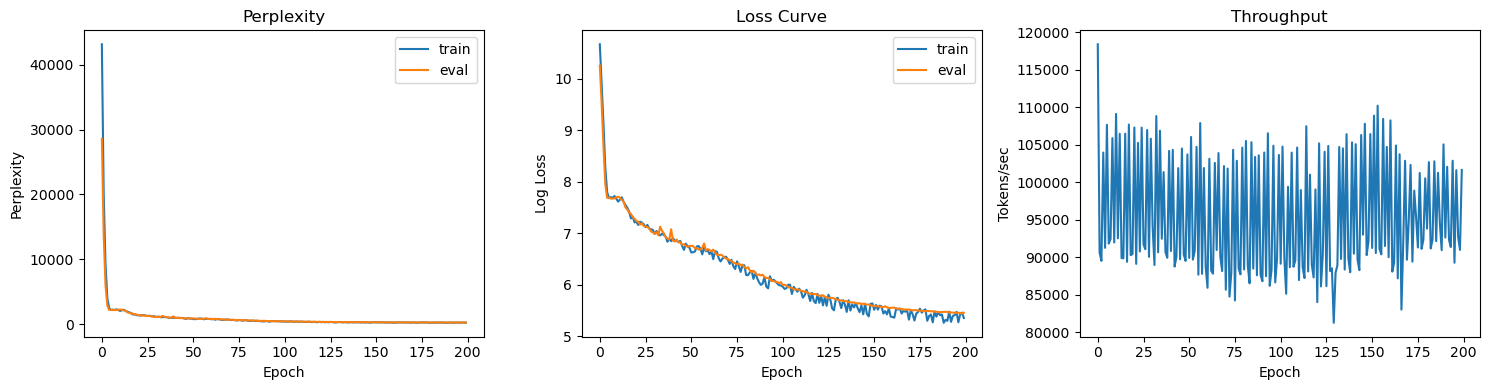

Parameters: 29,989,585
Peak GPU memory: 15.53 GB


In [85]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_ppls, label='train')
axes[0].plot(eval_ppls, label='eval')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Perplexity')
axes[0].legend()
axes[0].set_title('Perplexity')

axes[1].plot([math.log(p) for p in train_ppls], label='train')
axes[1].plot([math.log(p) for p in eval_ppls], label='eval')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Log Loss')
axes[1].legend()
axes[1].set_title('Loss Curve')

axes[2].plot(tokens_per_sec)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Tokens/sec')
axes[2].set_title('Throughput')

plt.tight_layout()
plt.show()

print(f'Parameters: {sum(p.numel() for p in net.parameters() if p.requires_grad):,}')
print(f'Peak GPU memory: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB')

## Text generation
Autoregressive generation: feed the prompt, sample one token, append it, repeat.  
Supports **greedy**, **top-k**, and **top-p (nucleus)** decoding with temperature scaling.

In [86]:
# load best checkpoint for inference
checkpoint = torch.load(checkpoint_path, weights_only=False)
net.load_state_dict(checkpoint['model_state_dict'])
net.eval()
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}, eval ppl = {math.exp(checkpoint['eval_loss']):.2f}")

Loaded checkpoint from epoch 198, eval ppl = 232.12


In [87]:
@torch.no_grad()
def generate(prompt, max_new_tokens=100, temperature=1.0, top_k=0, top_p=0.0):
    """
    Autoregressive text generation from a prompt string.
    
    Args:
        prompt:          seed text
        max_new_tokens:  how many tokens to generate
        temperature:     >1 = more random, <1 = more focused, 1 = unchanged
        top_k:           if >0, only sample from the top-k most likely tokens
        top_p:           if >0, nucleus sampling — sample from smallest set with cumulative prob >= top_p
    """
    net.eval()
    token_ids = tokenizer.encode(prompt)

    for _ in range(max_new_tokens):
        # truncate context to seq_length if it grows too long
        context = token_ids[-seq_length:]
        x = torch.LongTensor(context).unsqueeze(1).to(device)  # (ctx_len, 1)
        pos = generate_positional_encoding(x.size(0), hidden_size).to(device)

        # forward pass with batch_size=1
        scores = net(x, pos)       # (ctx_len, 1, vocab_size)
        logits = scores[-1, 0, :]  # last position logits, (vocab_size,)

        # temperature scaling
        if temperature != 1.0:
            logits = logits / temperature

        # top-k filtering
        if top_k > 0:
            topk_vals, _ = torch.topk(logits, top_k)
            logits[logits < topk_vals[-1]] = float('-inf')

        # top-p (nucleus) filtering
        if top_p > 0.0:
            sorted_logits, sorted_idx = torch.sort(logits, descending=True)
            cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=0), dim=0)
            # remove tokens with cumulative prob above the threshold (keep first token above)
            remove_mask = cumulative_probs - F.softmax(sorted_logits, dim=0) >= top_p
            sorted_logits[remove_mask] = float('-inf')
            logits = sorted_logits.scatter(0, sorted_idx, sorted_logits)

        probs = F.softmax(logits, dim=0)

        # greedy vs sampling
        if temperature == 0 or (top_k == 0 and top_p == 0.0):
            next_token = torch.argmax(probs).item()
        else:
            next_token = torch.multinomial(probs, 1).item()

        # stop on EOS
        if next_token == eos_token_id:
            break

        token_ids.append(next_token)

    return tokenizer.decode(token_ids)

In [88]:
# sample prompts
prompts = [
    "My social security number is"
]

for p in prompts:
    print("=" * 70)
    print(f"PROMPT: {p}")
    print("-" * 70)

    print("\n[Greedy]")
    print(generate(p, max_new_tokens=100))

    print("\n[Top-k=50, temp=0.8]")
    print(generate(p, max_new_tokens=100, temperature=0.8, top_k=50))

    print("\n[Nucleus p=0.9, temp=0.9]")
    print(generate(p, max_new_tokens=100, temperature=0.9, top_p=0.9))
    print()

PROMPT: My social security number is
----------------------------------------------------------------------

[Greedy]
My social security number is a major source of the most important way to be a good way to be a good way to understand the future.
The first step of the world is to be a good way to be a good way to be a good way to be a good way to be a good way.
The first step is to be a good way to be a good way to be a good way to be a good way to be a good way.
The first step is to be a good way to be

[Top-k=50, temp=0.8]
My social security number is the best news that the most important way we can have no potential problems. It is best to learn about a new course.
Here are two advantages, the same problem, the most important choice is not the main example of the best, when it is still that is a more meaningful way of being used.
So it is a good example of this question?
- Who's best on all the world?
- What is the same thing?
Most people are the most likely to know

[Nucleus p=0.9